In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [2]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

In [4]:
import pickle

import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from yellowbrick.classifier import ConfusionMatrix

# Support Vector Machine - SVM

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem em que salvou.


In [5]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'
with open(os.path.join(DRIVE_DIRECTORY_fonte, "cover_type_exer3.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Use o atributo `shape` para verificar quantas instâncias e quantos atributos têm as variáveis do split de treinamento.

In [6]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

# Agora instancie e ajuste um classificador do tipo `SVC`. Utilize `kernel='rbf'` e `random_state=0`.

In [9]:
# SVC: Procura a maior distância (margem) possível entre as classes de árvores
# kernel='rbf': Permite criar divisões curvas, ideal para dados complexos
sv_classifier = SVC(kernel='rbf', random_state=0)
# Treina o modelo: Encontra os 'Vetores de Suporte' (pontos críticos na borda)
sv_classifier.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
# --- RESUMO DOS PARÂMETROS ---
# C=1.0: Controla o equilíbrio entre erro no treino e margem larga
# gamma='scale': Define o quão longe a influência de cada ponto alcança
# max_iter=-1: O modelo rodará até encontrar a solução ideal (sem limite de tempo)

In [11]:
sv_classifier.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 0,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

Entendendo os Parâmetros (O dicionário)

- C: 1.0: É o parâmetro de penalidade.

Um C alto tenta acertar todos os pontos de treino, mas pode criar fronteiras muito complexas.

Um C baixo permite alguns erros para garantir uma fronteira mais suave (generalista).

- kernel: 'rbf': Define que a fronteira será não-linear (curva). É o kernel mais usado por ser muito flexível.

- gamma: 'scale': Controla o "raio" de influência de um único ponto de treino. 'scale' ajusta isso automaticamente com base nos seus dados.

- decision_function_shape: 'ovr': Significa One-vs-Rest. Como o SVM original só separa duas coisas, o ovr permite que ele classifique os vários tipos de árvores comparando um tipo contra todos os outros.

### Faça e exiba a predição no split de teste.

In [12]:
y_pred = sv_classifier.predict(X_test)
y_pred

array([4, 4, 5, ..., 6, 6, 5], shape=(2500,))

Calcule a acurácia.

In [13]:
accuracy_score(y_test, y_pred)

0.7672

In [14]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100:.2f} % de acurácia ou acerto')

tivemos 76.72 % de acurácia ou acerto


Exiba a matriz de confusão.

0.7672

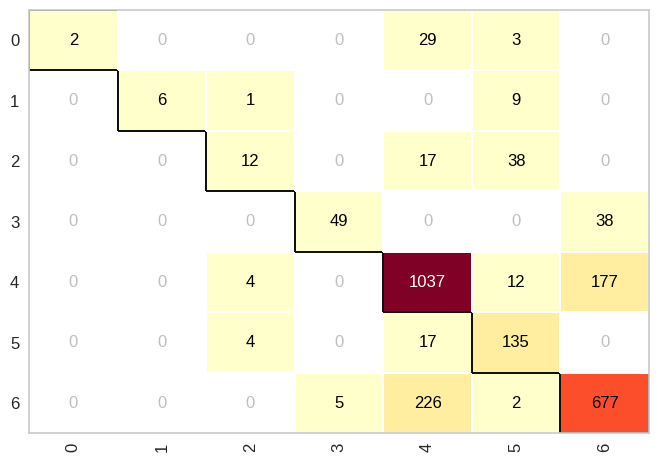

In [15]:
cm = ConfusionMatrix(sv_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Eixo Vertical (True Class): É a realidade. O que realmente é no mundo real.

#### Eixo Horizontal (Predicted Class): É o palpite do modelo. O que o SMV achou que era.

Exiba o reporte de classificação.

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.06      0.11        34
           1       1.00      0.38      0.55        16
           2       0.57      0.18      0.27        67
           3       0.91      0.56      0.70        87
           4       0.78      0.84      0.81      1230
           5       0.68      0.87      0.76       156
           6       0.76      0.74      0.75       910

    accuracy                           0.77      2500
   macro avg       0.81      0.52      0.56      2500
weighted avg       0.77      0.77      0.76      2500



In [17]:
# melhorou os dados, todas as classes são boas, e também as problemáticas, 0 e 1, com precisão boas

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

In [18]:
# o ideal é o Precision e o Recall elevados, bem próximo de 1.

In [19]:
from sklearn.preprocessing import LabelEncoder

# # 1. Recriamos o objeto
# label_encoder = LabelEncoder()

# # 2. "Ensinamos" a ele os nomes novamente usando a coluna original do DataFrame
# # Isso restaura a memória do encoder (o mapeamento de nomes para números)
# label_encoder.fit(base['Cover_Type'])

# # 3. Agora o comando vai funcionar!
# y_pred_strings = label_encoder.inverse_transform(y_pred)
# y_test_strings = label_encoder.inverse_transform(y_test)

# print("Nomes traduzidos com sucesso!")
# print(label_encoder.classes_)

#---------------------------------------

# # 1. Primeiro, geramos as previsões (que virão como números: 0, 1, 2...)
# y_pred = naive_classifier.predict(X_test)

# # 2. Agora, traduzimos os números de volta para os nomes das árvores
# y_pred_strings = label_encoder.inverse_transform(y_pred)

# # 3. Fazemos o mesmo para o y_test para podermos comparar "Nome vs Nome"
# y_test_strings = label_encoder.inverse_transform(y_test)

# # 4. Criamos uma tabela para você ver os 10 primeiros resultados reais
# import pandas as pd
# df_resultados = pd.DataFrame({
#     'Classe Real': y_test_strings,
#     'Previsão do Modelo': y_pred_strings
# })

# print("--- Primeiros 10 resultados traduzidos ---")
# print(df_resultados.head(10))
#----------------------------------

# # 1. Converte o array de números (y_pred) para os nomes originais (strings)
# y_pred_nomes = label_encoder.inverse_transform(y_pred)

# # 2. Se quiser ver os nomes reais do conjunto de teste para comparar
# y_test_nomes = label_encoder.inverse_transform(y_test)

# # 3. Vamos ver os 10 primeiros resultados lado a lado
# import pandas as pd
# comparacao = pd.DataFrame({
#     'Real': y_test_nomes,
#     'Previsão': y_pred_nomes
# })

# print(comparacao.head(10))

# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb


In [20]:
# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb
# y = base.iloc[:, -1].values
# base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta
# 'Cover_Type'

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)
# # Mostra a lista de nomes na ordem (0, 1, 2...)
# print(label_encoder.classes_)
# {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}



In [21]:
import pandas as pd

# O seu dicionário de mapeamento
mapa_nomes = {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 
              3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 
              6: 'Spruce/Fir'}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapa_nomes)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapa_nomes)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Lodgepole Pine
1,Lodgepole Pine,Lodgepole Pine
2,Cottonwood/Willow,Ponderosa Pine
3,Lodgepole Pine,Lodgepole Pine
4,Lodgepole Pine,Lodgepole Pine
5,Spruce/Fir,Spruce/Fir
6,Lodgepole Pine,Lodgepole Pine
7,Spruce/Fir,Spruce/Fir
8,Lodgepole Pine,Lodgepole Pine
9,Lodgepole Pine,Lodgepole Pine
